<a href="https://colab.research.google.com/github/rahma1ayman/Skin-Lesion-Segmentation/blob/main/Skin_Lesion_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Skin Lesion Segmentation using Transformer-based Model (SegFormer)**

This project focuses on applying deep learning techniques for medical image segmentation, specifically targeting the detection and localization of skin lesions from dermoscopic images.

**Dataset**

The model is trained on the ISIC 2018 dataset, which contains:

*   High-resolution dermoscopic images of skin lesions
*   Corresponding segmentation masks indicating the exact location of the lesion

**Model**

We use SegFormer, a transformer-based architecture designed for semantic segmentation.

**Evaluation Metrics**

To assess performance, we use:
* Mean Intersection over Union (Mean IoU): measures overlap between predicted and ground truth masks
* Mean Accuracy: evaluates pixel-wise classification accurac

**Conclusion**

This project demonstrates the effectiveness of Transformer-based models in medical image segmentation tasks. By combining pretrained architectures with domain-specific datasets, the model is able to accurately localize skin lesions, which can assist in early diagnosis and clinical decision support.








In [1]:
! pip install transformers datasets torchvision torch

In [2]:
!pip install datasets transformers evaluate accelerate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.6 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
import torch
device = torch.device("cuda")
print(torch.cuda.is_available())

True


In [13]:
from datasets import load_dataset
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation
import numpy as np


In [5]:

dataset = load_dataset(
    "surajbijjahalli/ISIC2018",
    cache_dir="/content/drive/MyDrive/hf_cache"
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/709 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/50 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/50 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/50 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/50 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/50 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/50 [00:00<?, ?it/s]

In [6]:
dataset.save_to_disk("/content/drive/MyDrive/isic_dataset")

Saving the dataset (0/23 shards):   0%|          | 0/2594 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/100 [00:00<?, ? examples/s]

Saving the dataset (0/5 shards):   0%|          | 0/1000 [00:00<?, ? examples/s]

In [7]:
print(dataset)
print(dataset["train"].features)
print(dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 2594
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 100
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 1000
    })
})
{'image': Image(mode=None, decode=True), 'label': Image(mode=None, decode=True)}
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1022x767 at 0x7BDE284B5550>, 'label': <PIL.PngImagePlugin.PngImageFile image mode=L size=1022x767 at 0x7BDE284B77D0>}


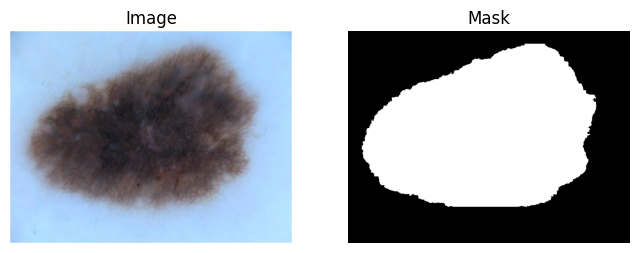

In [8]:
import matplotlib.pyplot as plt

sample = dataset["train"][0]

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(sample["image"])
plt.title("Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(sample["label"], cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.show()

In [9]:
#load processor
processor = SegformerImageProcessor.from_pretrained(
    "nvidia/segformer-b0-finetuned-ade-512-512"
)

preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/image_processing_base.py:370: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


In [10]:

def transform(examples):
    images = [img.convert("RGB") for img in examples["image"]]
    masks = [np.array(m) for m in examples["label"]]

    # نحول masks لـ binary
    masks = [(m > 0).astype(np.uint8) for m in masks]

    inputs = processor(
        images=images,
        segmentation_maps=masks,
        return_tensors="pt"
    )

    return {
        "pixel_values": inputs["pixel_values"],
        "labels": inputs["labels"]
    }

In [11]:
# Apply processor on data
processed_dataset = dataset.with_transform(transform)

In [12]:
sample = processed_dataset["train"][0]

print("pixel_values shape:", sample["pixel_values"].shape)
print("labels shape:", sample["labels"].shape)
print("unique mask values:", sample["labels"].unique())

pixel_values shape: torch.Size([3, 512, 512])
labels shape: torch.Size([512, 512])
unique mask values: tensor([0, 1])


In [17]:
# Load segFormer Model
id2label = {
    0: "background",
    1: "lesion"
}

label2id = {
    "background": 0,
    "lesion": 1
}

model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b0-finetuned-ade-512-512",
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

model.to(device)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([2, 256, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([2])                      

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


SegformerForSemanticSegmentation(
  (segformer): SegformerModel(
    (encoder): SegformerEncoder(
      (patch_embeddings): ModuleList(
        (0): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(3, 32, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
          (layer_norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        )
        (1): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        )
        (2): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(64, 160, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((160,), eps=1e-05, elementwise_affine=True)
        )
        (3): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(160, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  

In [18]:
!pip install evaluate -q

In [19]:

import evaluate
from transformers import TrainingArguments, Trainer

metric = evaluate.load("mean_iou")

In [20]:
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/segformer_isic_results",
    learning_rate=6e-5,
    num_train_epochs=5,

    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=20,

    load_best_model_at_end=True,
    metric_for_best_model="mean_iou",
    greater_is_better=True,

    remove_unused_columns=False,
    optim="adamw_torch"
)

In [21]:
# evaluation
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    logits = torch.tensor(logits)
    logits = torch.nn.functional.interpolate(
        logits,
        size=labels.shape[-2:],
        mode="bilinear",
        align_corners=False
    )

    preds = logits.argmax(dim=1).numpy()

    metrics = metric.compute(
        predictions=preds,
        references=labels,
        num_labels=2,
        ignore_index=255,
        reduce_labels=False
    )

    return {
        "mean_iou": metrics["mean_iou"],
        "mean_accuracy": metrics["mean_accuracy"]
    }

In [23]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=processed_dataset["train"],
    eval_dataset=processed_dataset["validation"],
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Mean Iou,Mean Accuracy
1,0.150632,0.134373,0.873087,0.941702
2,0.116483,0.114501,0.892377,0.953258
3,0.072070,0.126992,0.881457,0.940208
4,0.102014,0.139631,0.871460,0.950051
5,0.075247,0.149859,0.870782,0.947099


/usr/local/lib/python3.12/dist-packages/datasets/features/image.py:357: UserWarning: Downcasting array dtype int64 to int32 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible with 'Pillow'")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/datasets/features/image.py:357: UserWarning: Downcasting array dtype int64 to int32 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible with 'Pillow'")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

/usr/local/lib/python3.12/dist-packages/datasets/features/image.py:357: UserWarning: Downcasting array dtype int64 to int32 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible with 'Pillow'")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/datasets/features/image.py:357: UserWarning: Downcasting array dtype int64 to int32 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible with 'Pillow'")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3245, training_loss=0.11233453884697842, metrics={'train_runtime': 4307.0822, 'train_samples_per_second': 3.011, 'train_steps_per_second': 0.753, 'total_flos': 2.2733758311432192e+17, 'train_loss': 0.11233453884697842, 'epoch': 5.0})

In [24]:
trainer.save_model("/content/drive/MyDrive/segformer_isic_best")
processor.save_pretrained("/content/drive/MyDrive/segformer_isic_best")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['/content/drive/MyDrive/segformer_isic_best/preprocessor_config.json']

In [25]:

model.eval()

sample = dataset["test"][0]

image = sample["image"]
mask = sample["label"]

inputs = processor(images=image, return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits

logits = torch.nn.functional.interpolate(
    logits,
    size=image.size[::-1],
    mode="bilinear",
    align_corners=False
)

pred_mask = logits.argmax(dim=1).squeeze().cpu().numpy()

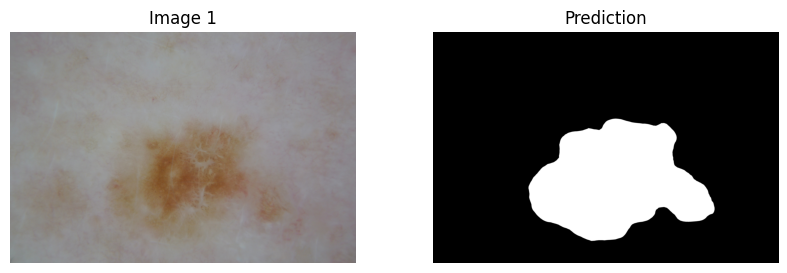

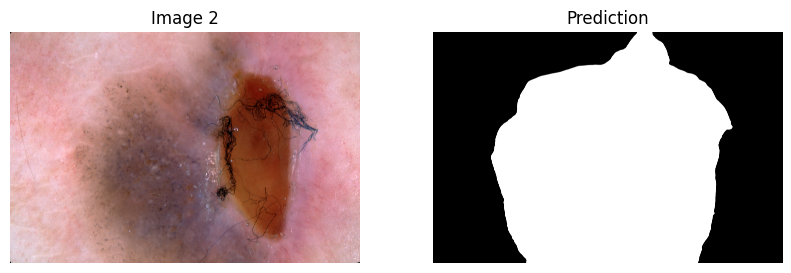

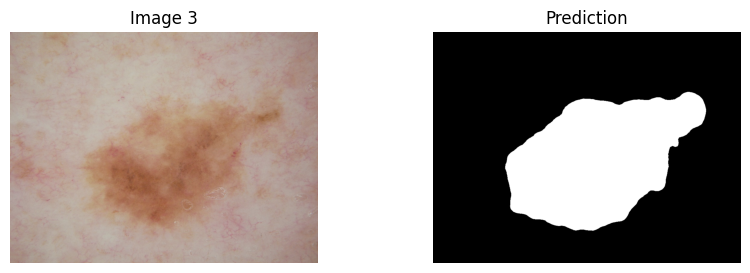

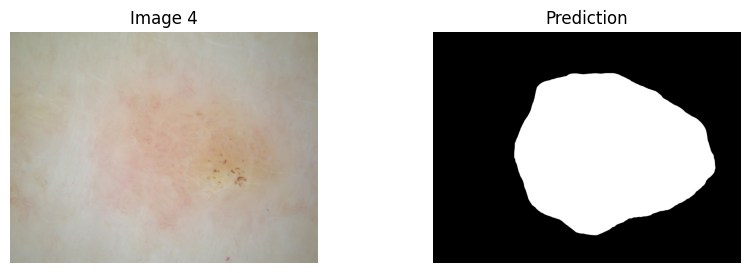

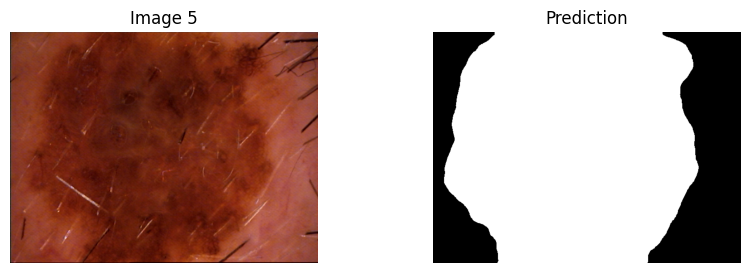

In [28]:
import random

model.eval()

num_samples = 5

indices = random.sample(range(len(dataset["test"])), num_samples)

for i, idx in enumerate(indices):

    sample = dataset["test"][idx]

    image = sample["image"]

    inputs = processor(images=image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits

    logits = torch.nn.functional.interpolate(
        logits,
        size=image.size[::-1],
        mode="bilinear",
        align_corners=False
    )

    pred_mask = logits.argmax(dim=1).squeeze().cpu().numpy()

    # عرض الصورة
    plt.figure(figsize=(10,3))

    plt.subplot(1,2,1)
    plt.imshow(image)
    plt.title(f"Image {i+1}")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(pred_mask, cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

    plt.show()